REPORT:US_BIRTHS_2000-2014_SSA

ABSTRACT:
This study analyzes the US Births dataset (2000–2014) from the Social Security Administration (SSA). The aim is to understand patterns in the number of births recorded each day. The analysis focuses on differences in birth counts across days of the week and throughout the year. It also examines trends, variations, and distribution in the data while considering unusual or irregular values. The results help provide insights into birth patterns over time.


In [4]:
#to import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#read the dataset into a dataframe in pandas
import pandas as pd
df = pd.read_csv("C:/Users/manoj/Downloads/US_births_2000-2014_SSA (1).csv") 
print(df)

      year  month  date_of_month  day_of_week   births        date
0     2000      1            1.0            6   9083.0  01-01-2000
1     2000      1            2.0            7   8006.0  01-02-2000
2     2000      1            3.0            1  11363.0  01-03-2000
3     2000      1            4.0            2  13032.0  01-04-2000
4     2000      1            5.0            3  12558.0  01-05-2000
...    ...    ...            ...          ...      ...         ...
5474  2014     12           27.0            6   8656.0  12/27/2014
5475  2014     12           28.0            7   7724.0  12/28/2014
5476  2014     12           29.0            1  12811.0  12/29/2014
5477  2014     12           30.0            2  13634.0  12/30/2014
5478  2014     12            NaN            3  11990.0  12/31/2014

[5479 rows x 6 columns]


In [5]:
#to display 1st 5 rows
print(df.head())

   year  month  date_of_month  day_of_week   births        date
0  2000      1            1.0            6   9083.0  01-01-2000
1  2000      1            2.0            7   8006.0  01-02-2000
2  2000      1            3.0            1  11363.0  01-03-2000
3  2000      1            4.0            2  13032.0  01-04-2000
4  2000      1            5.0            3  12558.0  01-05-2000


In [6]:
# to check dataset information
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 5479 entries, 0 to 5478
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           5479 non-null   int64  
 1   month          5479 non-null   int64  
 2   date_of_month  5478 non-null   float64
 3   day_of_week    5479 non-null   int64  
 4   births         5465 non-null   float64
 5   date           5479 non-null   str    
dtypes: float64(2), int64(3), str(1)
memory usage: 308.0 KB
None
              year        month  date_of_month  day_of_week        births
count  5479.000000  5479.000000    5478.000000  5479.000000   5465.000000
mean   2006.999270     6.522723      15.727455     3.999817  11348.814456
std       4.321085     3.449075       8.799535     2.000502   2327.445105
min    2000.000000     1.000000       1.000000     1.000000   5728.000000
25%    2003.000000     4.000000       8.000000     2.000000   8739.000000
50%    2007.000000     7.000000      16.0000

DATA-PREPROCESSING


In [ ]:
# TO CHECK THE MISSING VALUES
print(df.isnull().sum())


year              0
month             0
date_of_month     1
day_of_week       0
births           14
date              0
dtype: int64


In [11]:
#Remove all the rows corresponding to holidays
df = df[df["births"] > 10000]
print(df)

      year  month  date_of_month  day_of_week   births        date
2     2000      1            3.0            1  11363.0  01-03-2000
3     2000      1            4.0            2  13032.0  01-04-2000
4     2000      1            5.0            3  12558.0  01-05-2000
6     2000      1            7.0            5  12516.0  01-07-2000
9     2000      1           10.0            1  11668.0  01-10-2000
...    ...    ...            ...          ...      ...         ...
5470  2014     12           23.0            2  12604.0  12/23/2014
5473  2014     12           26.0            5  10386.0  12/26/2014
5476  2014     12           29.0            1  12811.0  12/29/2014
5477  2014     12           30.0            2  13634.0  12/30/2014
5478  2014     12            NaN            3  11990.0  12/31/2014

[3790 rows x 6 columns]


In [12]:
#Remove all the rows on weekdays that are less than 10,000
df = df[df["births"] >= 10000]
print(df)

      year  month  date_of_month  day_of_week   births        date
2     2000      1            3.0            1  11363.0  01-03-2000
3     2000      1            4.0            2  13032.0  01-04-2000
4     2000      1            5.0            3  12558.0  01-05-2000
6     2000      1            7.0            5  12516.0  01-07-2000
9     2000      1           10.0            1  11668.0  01-10-2000
...    ...    ...            ...          ...      ...         ...
5470  2014     12           23.0            2  12604.0  12/23/2014
5473  2014     12           26.0            5  10386.0  12/26/2014
5476  2014     12           29.0            1  12811.0  12/29/2014
5477  2014     12           30.0            2  13634.0  12/30/2014
5478  2014     12            NaN            3  11990.0  12/31/2014

[3790 rows x 6 columns]


In [13]:
#the average number of births per day for each day of the week
average_births = df.groupby("day_of_week")["births"].mean()
print(average_births)

day_of_week
1    12145.919837
2    13191.042857
3    12967.827497
4    13009.237086
5    12708.005284
6    10499.000000
Name: births, dtype: float64


In [14]:
#the median number of births per day for each day of the week
median_births=df.groupby("day_of_week")["births"].median()
print(median_births)

day_of_week
1    12141.5
2    13206.0
3    12949.0
4    12985.0
5    12667.0
6    10499.0
Name: births, dtype: float64


In [15]:
#How dispersed are the number of births per day for each day of the week
#using standard deviation
dispersion=df.groupby("day_of_week")["births"].std()
print(dispersion)

day_of_week
1    628.929305
2    685.675857
3    736.101952
4    723.970982
5    750.823985
6           NaN
Name: births, dtype: float64


In [16]:
#the interquartile range (IQR) of the number of births per day for each day of the week
Q1 = df.groupby("day_of_week")["births"].quantile(0.25)
Q3 = df.groupby("day_of_week")["births"].quantile(0.75)

IQR = Q3 - Q1
print(IQR)

day_of_week
1    863.50
2    883.25
3    936.00
4    947.00
5    947.00
6      0.00
Name: births, dtype: float64


In [17]:
# to find the outliers using the IQR method
Q1 = df["births"].quantile(0.25)
Q3 = df["births"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["births"] < lower) | (df["births"] > upper)]

print(outliers)


      year  month  date_of_month  day_of_week   births        date
51    2000      2           21.0            1  10610.0   2/21/2000
360   2000     12           26.0            2  10395.0  12/26/2000
367   2001      1            2.0            2  10635.0  01-02-2001
415   2001      2           19.0            1  10522.0   2/19/2001
730   2001     12           31.0            1  10272.0  12/31/2001
821   2002      4            1.0            1  10264.0  04-01-2002
1143  2003      2           17.0            1  10707.0   2/17/2003
1455  2003     12           26.0            5  10431.0  12/26/2003
1462  2004      1            2.0            5  10586.0  01-02-2004
1826  2004     12           31.0            5  10130.0  12/31/2004
2130  2005     10           31.0            1  10207.0  10/31/2005
2183  2005     12           23.0            5  10642.0  12/23/2005
2378  2006      7            6.0            4  15007.0  07-06-2006
2440  2006      9            6.0            3  15391.0  09-06-

DATA VISUALIZATION


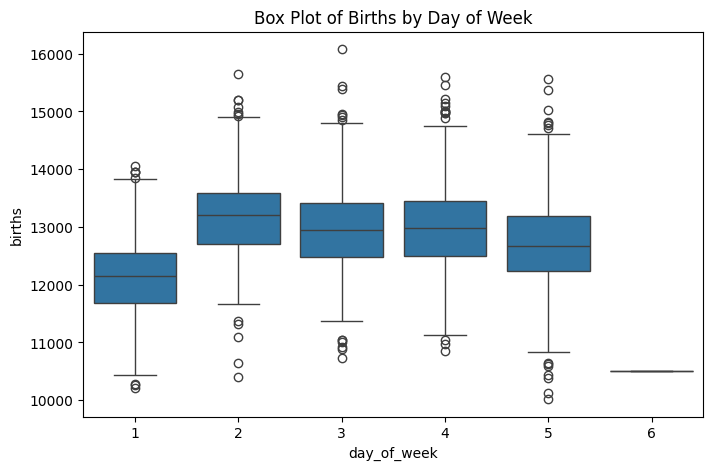

In [18]:
#Produce box and whisker plots
plt.figure(figsize=(8,5))
sns.boxplot(x="day_of_week", y="births", data=df)

plt.title("Box Plot of Births by Day of Week")
plt.show()

The box and whisker plot shows the distribution of daily birth counts for each day of the week. The box represents the interquartile range (IQR), which contains the middle 50% of the data, while the line inside the box indicates the median number of births. The whiskers extend to the minimum and maximum values excluding outliers, and any points outside the whiskers represent outliers. From the plot, we can observe how birth counts vary across different days of the week and identify days with higher variability or unusual values. This visualization helps in understanding the spread, central tendency, and presence of outliers in the birth data.

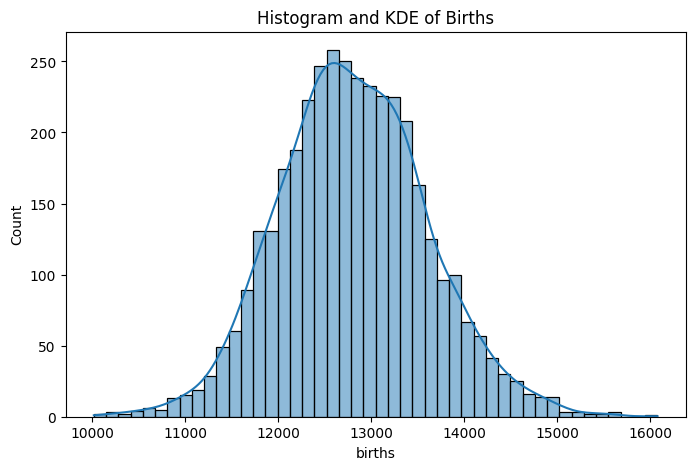

In [19]:
# Produce histograms and KDE plots
plt.figure(figsize=(8,5))
sns.histplot(df["births"], kde=True)

plt.title("Histogram and KDE of Births")
plt.show()


The histogram shows the distribution of daily birth counts, indicating how frequently different birth values occur. The KDE (Kernel Density Estimate) curve provides a smooth line that represents the overall pattern of the distribution. From the graph, we can observe the general trend and concentration of birth counts and understand whether the data is normally distributed or skewed.

In [22]:
#Find by what day of the year 50% of births have occurred for each year
# create date column
df["date"] = pd.to_datetime({
    "year": df["year"],
    "month": df["month"],
    "day": df["date_of_month"]
})

# find day of year
df["day_of_year"] = df["date"].dt.dayofyear

# cumulative births per year
births_cumsum = df.groupby(["year","day_of_year"])["births"].sum().groupby(level=0).cumsum()

# total births per year
total_births = df.groupby("year")["births"].sum()

# proportion of births
result = births_cumsum / total_births

# day when 50% births occurred
day_50 = result[result >= 0.5].groupby("year").idxmin()

print(day_50)

year
2000    (2000, 189.0)
2001    (2001, 184.0)
2002    (2002, 184.0)
2003    (2003, 184.0)
2004    (2004, 188.0)
2005    (2005, 186.0)
2006    (2006, 187.0)
2007    (2007, 184.0)
2008    (2008, 183.0)
2009    (2009, 183.0)
2010    (2010, 183.0)
2011    (2011, 186.0)
2012    (2012, 187.0)
2013    (2013, 186.0)
2014    (2014, 184.0)
Name: births, dtype: object


In [23]:
#In 2000, between what days of the year do 50% of births occur
df2000 = df[df["year"] == 2000]

cum_births = df2000.groupby("day_of_year")["births"].sum().cumsum()

total = cum_births.iloc[-1]

start = cum_births[cum_births >= total * 0.25].index[0]
end = cum_births[cum_births >= total * 0.75].index[0]

print(start, end)

95.0 273.0
